# Finance Analyzer Demo

This notebook shows how to use `finance_analyzer` as a library, step by step.
It uses the sample data that comes with the project, so you can run every cell yourself.

In [25]:
from IPython.display import Image, display

from finance_analyzer import (
    Account,
    find_recurring,
    forecast_balance,
    get_advice,
    save_all_plots,
)

## 1. Load a bank statement

`Account.from_csv` reads the file and gives every transaction a category.
The sample file has no balance column, so the starting balance (1000 €) is given by hand.

In [26]:
account = Account.from_csv("../data/sample_transactions.csv", starting_balance=1000)
account

Account(379 transactions, balance=6296.85)

The transactions as a table, with the balance after each one:

In [27]:
account.to_dataframe().head()

,date,description,amount,category,month,balance
0,2025-10-01,Rent,-750.00,Housing,2025-10,250.00
1,2025-10-01,Netflix,-12.99,Subscriptions,2025-10,237.01
2,2025-10-01,dm Drogerie,-22.43,Health & Care,2025-10,214.58
3,2025-10-03,Deutschlandticket,-58.00,Transport,2025-10,156.58
4,2025-10-03,Amazon,-62.29,Shopping,2025-10,94.29


## 2. Monthly summary

Income, expenses, and what is left (net) for every month.

In [28]:
account.monthly_summary()

,income,expenses,net
month,,,
2025-10,2100.0,-1584.59,515.41
2025-11,2100.0,-1516.88,583.12
2025-12,2100.0,-1838.24,261.76
2026-01,2100.0,-1645.89,454.11
2026-02,2100.0,-1632.99,467.01
2026-03,2100.0,-1856.36,243.64
2026-04,2100.0,-1854.69,245.31
2026-05,2100.0,-1640.39,459.61
2026-06,2100.0,-1269.24,830.76


## 3. Where does the money go?

The total spending per category, biggest first.

In [29]:
account.spending_by_category()

category
Housing          9000.00
Groceries        4131.66
Shopping         3002.30
Eating out       1376.89
Health & Care     862.78
Subscriptions     833.52
Transport         696.00
Name: amount, dtype: float64

## 4. Recurring payments

`find_recurring` looks for payments that come back regularly with about the same amount.
It does not know any names in advance.

In [30]:
payments = find_recurring(account)
for payment in payments:
    print(payment)

Rent                   -750.00 € monthly  (around day  1,  -9,000.00 € per year)
Deutschlandticket       -58.00 € monthly  (around day  3,    -696.00 € per year)
FitX Gym                -24.99 € monthly  (around day  5,    -299.88 € per year)
Vodafone Mobile         -19.99 € monthly  (around day 10,    -239.88 € per year)
Netflix                 -13.99 € monthly  (around day  1,    -167.88 € per year)
Spotify                 -10.99 € monthly  (around day 15,    -131.88 € per year)
Salary                2,100.00 € monthly  (around day 25,  25,200.00 € per year)


It also notices when a subscription got more expensive:

In [31]:
for payment in payments:
    if payment.yearly_increase > 0:
        print(
            f"{payment.description}: {-payment.first_amount:.2f} € -> {-payment.amount:.2f} € "
            f"({payment.yearly_increase:.2f} € more per year)"
        )

Netflix: 12.99 € -> 13.99 € (12.00 € more per year)


## 5. Balance forecast

A straight line is fitted through the balance at the end of each month and extended into the future.

In [32]:
forecast_balance(account, months=6).round(2)

2026-10    6647.35
2026-11    7076.37
2026-12    7505.39
2027-01    7934.40
2027-02    8363.42
2027-03    8792.44
Freq: M, Name: forecast, dtype: float64

## 6. Charts

The charts are saved as PNG files and shown here.

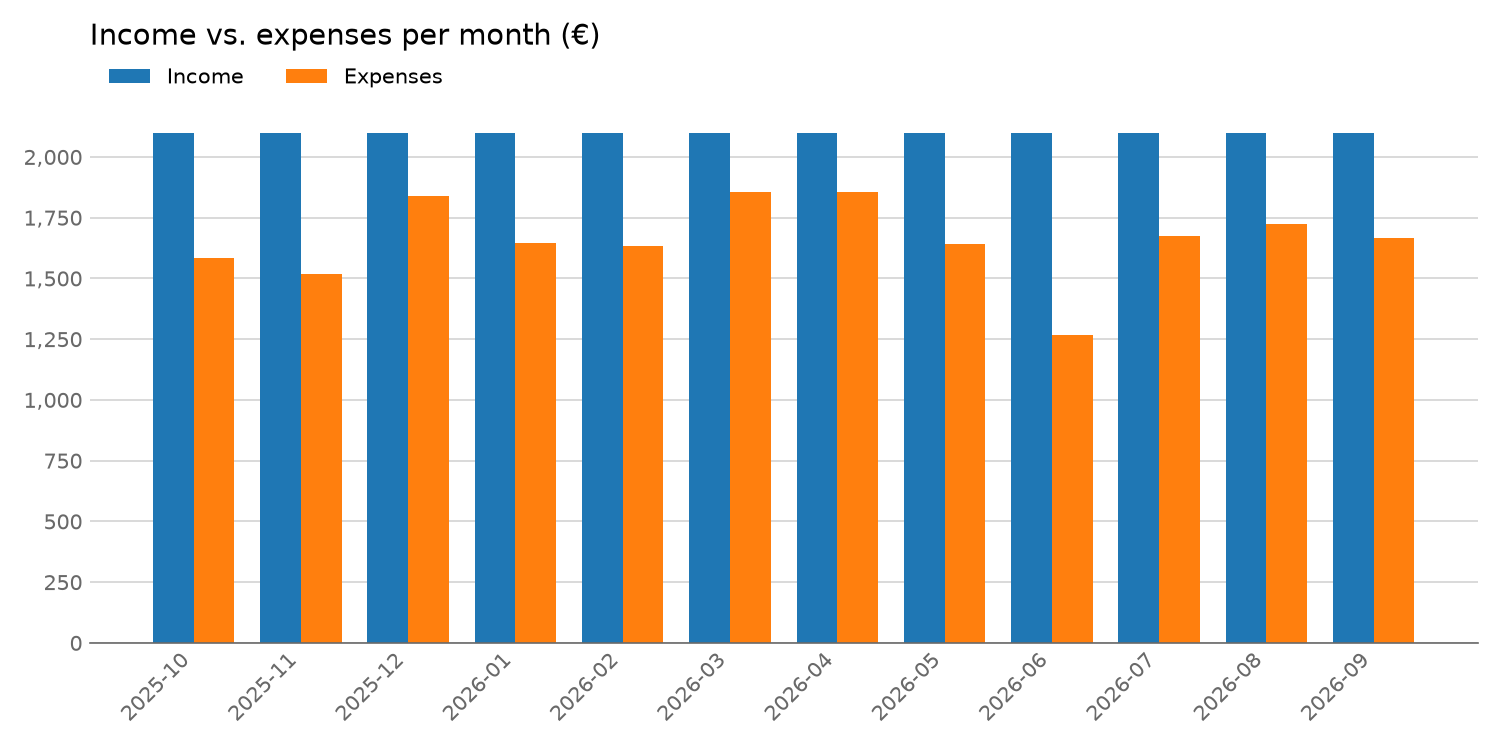

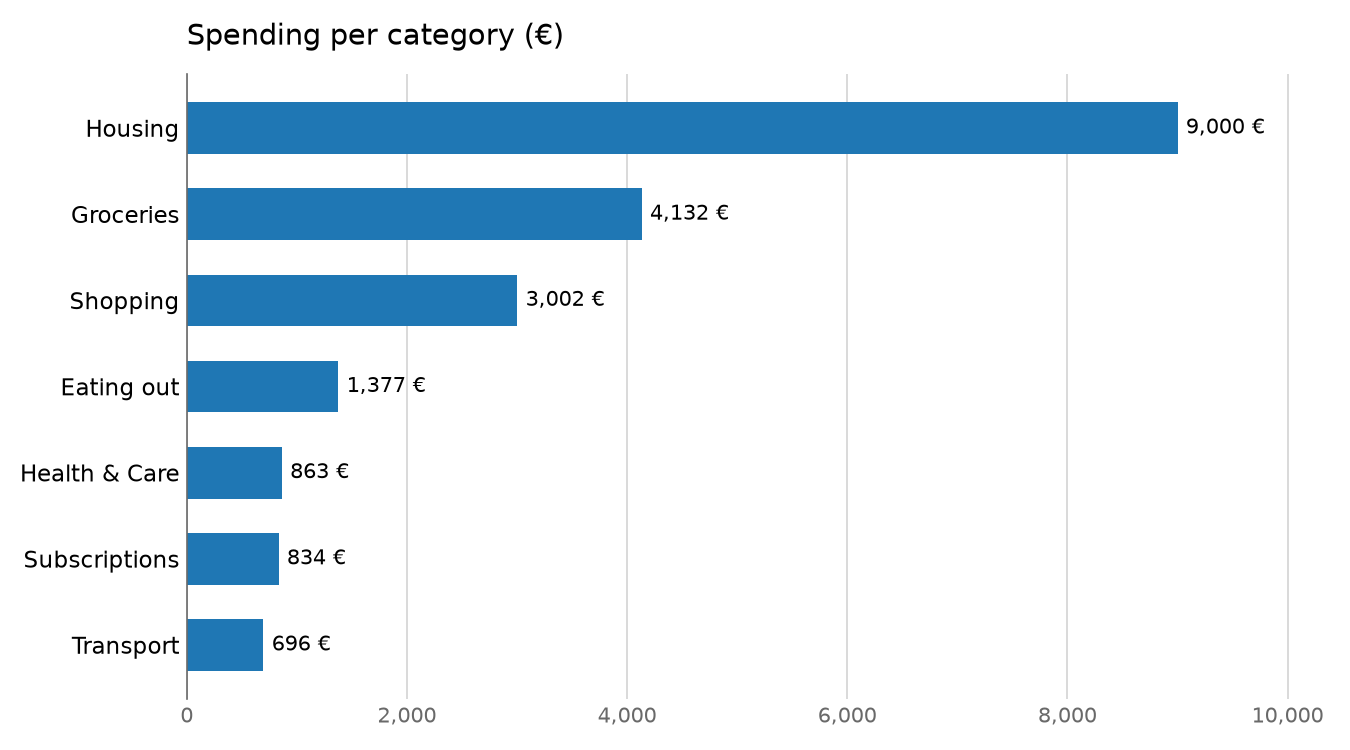

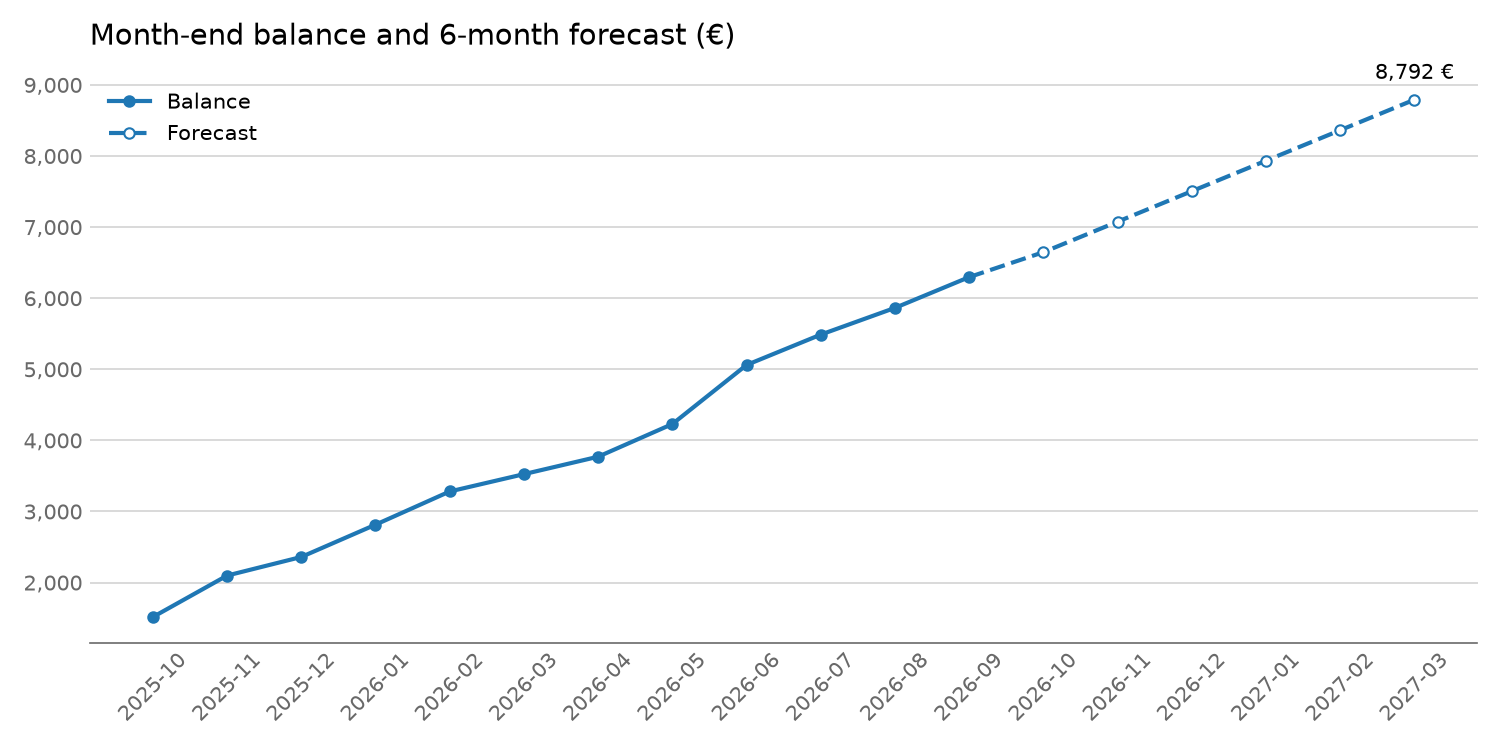

In [33]:
for path in save_all_plots(account, "../output"):
    display(Image(filename=path))

## 7. Saving tips

Each tip comes from a small rule that looks at one thing.

In [34]:
for tip in get_advice(account):
    print(tip)

[Good]    Great job! You save 21% of your income.
[Warning] Housing takes 36% of your income (recommended: under 30%).
[Tip]     You have 5 recurring payments (Deutschlandticket, FitX Gym, Vodafone Mobile, Netflix, Spotify) costing 1,535.52 € per year. Cancel the ones you don't use.
[Info]    Price increase: Netflix went from 12.99 € to 13.99 € (12.00 € more per year).
[Tip]     You spend 250.19 € per month on Shopping. Cutting it by a quarter would save 750.58 € per year.
[Info]    2026-03 was your weakest month: you saved only 243.64 €. Check what happened there.
[Good]    Your balance covers 3.8 months of expenses. Nice safety net!
[Info]    Your balance grows by 429.02 € per month. In 6 months you could have 8,792.44 €.


## 8. Other banks

The importer works out the layout of a file by itself: the separator, the columns,
and how dates and numbers are written. Here is a file in German format:

In [35]:
german = Account.from_csv("../data/example_german_bank.csv")
german.to_dataframe()[["date", "description", "amount", "category"]]

,date,description,amount,category
0,2025-10-01,Miete,-750.00,Housing
1,2025-10-01,Netflix,-12.99,Subscriptions
2,2025-10-04,REWE Markt,-43.17,Groceries
3,2025-10-25,Gehalt,2100.00,Income


And a Revolut statement. It has a balance column, so the starting balance is found automatically.
The cancelled payment in the file is skipped.

In [36]:
revolut = Account.from_csv("../data/example_revolut.csv")
print(f"Starting balance: {revolut.starting_balance:.2f} €")
print(f"Final balance:    {revolut.balance:.2f} €")
print("Skipped rows:    ", revolut.skipped_rows)

Starting balance: 100.00 €
Final balance:    536.05 €
Skipped rows:     ['line 4: payment not completed (REVERTED)']
